In [1]:
import numpy as np

import matplotlib.pyplot as plt

from delta_sigma_simulator.filter import FilterFirstOrder, FilterButterworth, FilterIntegrator
from delta_sigma_simulator.modulator import DeltaSigmaModulator
from delta_sigma_simulator.quantizer import QuantizerDelayHysteresis
from delta_sigma_simulator.wave import BinaryWave, SineWave

In [2]:
# Predicted self-oscillation frequency by this work
f0 = 1
# Corner frequency of the loop filter
fc = f0 * np.logspace(-3, 0, 100)
# Design parameter
mu = np.exp(np.pi * fc / f0) - 1
# Time delay of the quantizer
td = np.log(mu / 2 + 1) / (2 * np.pi * fc)
# Predicted self-oscillation frequency by A. Babaie-Fishani
f0_old = 1 / (4 * td) * (1 + 2 * np.pi * fc * td) / (1 + np.pi * fc * td)

In [ ]:
# Simulated self-oscillation frequency
f0_sim = np.zeros_like(fc)

for i, td_i in enumerate(td):
    loop_filter = FilterFirstOrder(f_p = fc[i], a = 1.0)
    quantizer = QuantizerDelayHysteresis(td_i, 0.0)
    quantizer.t_step = 0.1
    asdm = DeltaSigmaModulator(loop_filter, quantizer)
    v = asdm.simulate([], n=100)

    assert np.isclose(v.e[-1] - v.e[-3], v.e[-3] - v.e[-5]), "Simulation failed to converge."
        
    f0_sim[i] = 1 / (v.e[-1] - v.e[-3])

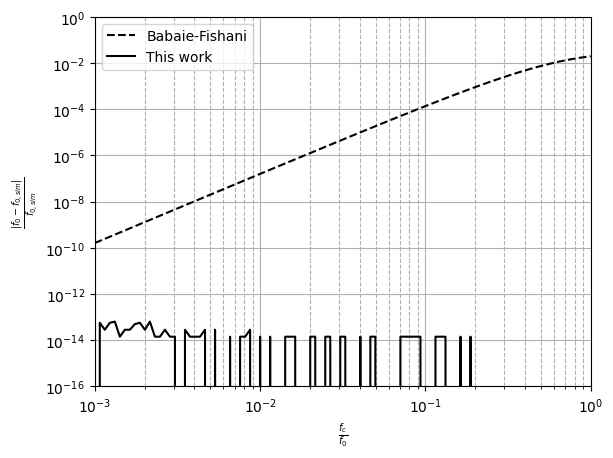

In [ ]:
plt.loglog(fc / f0, np.abs(f0_old - f0_sim) / f0_sim, 'k--', label="Babaie-Fishani")
plt.loglog(fc / f0, np.abs(f0     - f0_sim) / f0_sim, 'k-', label="This work")
plt.grid()
plt.grid(which='minor', linestyle='--')
plt.xlabel(r"$\frac{f_c}{f_0}$")
plt.ylabel(r"$\frac{|f_0-f_{0,sim}|}{f_{0,sim}}$")
plt.xlim(1e-3, 1e0)
plt.ylim(1e-16, 1e0)
plt.legend()
plt.show()

In [ ]:
np.savetxt("f-fc.csv", np.column_stack((fc / f0, np.abs(f0_old - f0_sim) / f0_sim, np.abs(f0 - f0_sim) / f0_sim)), delimiter=",")

In [ ]:
# Predicted self-oscillation frequency by this work
f0 = 1
# Corner frequency of the loop filter
fc = 1 
# Design parameter
mu = np.exp(np.pi * fc / f0) - 1
# Time delay of the quantizer
td = np.log(mu / 2 + 1) / (2 * np.pi * fc)
# Input signal to the SDM
U = np.linspace(-0.8, 0.8, 51)

In [ ]:
# Simulated self-oscillation frequency
f_sim = np.zeros_like(U)
# Simulated output voltage
V_sim = np.zeros_like(U)

loop_filter = FilterFirstOrder(f_p = fc, a = 1.0)
quantizer = QuantizerDelayHysteresis(td, 0.0)
quantizer.t_step = 0.1
asdm = DeltaSigmaModulator(loop_filter, quantizer)

for i, Ui in enumerate(U):
    v = asdm.simulate([BinaryWave(E=Ui)], n=100)

    assert np.isclose(v.e[-1] - v.e[-3], v.e[-3] - v.e[-5]), "Simulation failed to converge."
        
    f_sim[i] = 1 / (v.e[-1] - v.e[-3])

    V_sim[i] = v.E * (-1 + 2 * (v.e[-2] - v.e[-3]) / (v.e[-1] - v.e[-3]))

In [ ]:
# Predicted self-oscillation frequency
f2 = -np.pi * fc * (1 / 2 + 1 / mu)

f = f0 + f2 * V_sim ** 2
# Predicted self-oscillation frequency by A. Babaie-Fishani
f_old = 1 / (4 * td) * (1 + 2 * np.pi * fc * td) / (1 + np.pi * fc * td) * (1 - V_sim ** 2)

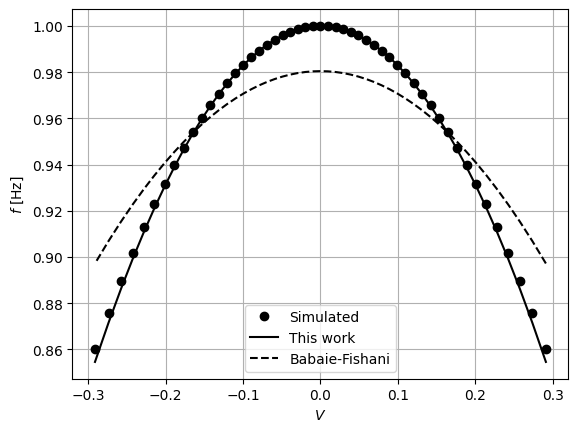

In [ ]:
plt.plot(V_sim, f_sim, 'ko', label="Simulated")
plt.plot(V_sim, f, 'k-', label="This work")
plt.plot(V_sim, f_old, 'k--', label="Babaie-Fishani")
plt.grid()
plt.grid(which='minor', linestyle='--')
plt.xlabel(r"$V$")
plt.ylabel(r"$f$ [Hz]")
plt.legend()
plt.show()

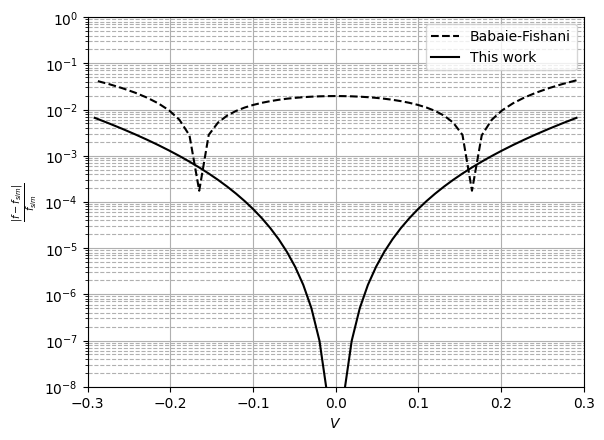

In [ ]:
plt.semilogy(V_sim, np.abs(f_old - f_sim) / f_sim, 'k--', label="Babaie-Fishani")
plt.semilogy(V_sim, np.abs(f     - f_sim) / f_sim, 'k-', label="This work")
plt.grid()
plt.grid(which='minor', linestyle='--')
plt.xlabel(r"$V$")
plt.ylabel(r"$\frac{|f-f_{sim}|}{f_{sim}}$")
plt.xlim(-0.3, 0.3)
plt.ylim(1e-8, 1e0)
plt.legend()
plt.show()

In [ ]:
np.savetxt("f-v.csv", np.stack([V_sim, f, f_old, f_sim, np.abs(f - f_sim) / f_sim, np.abs(f_old - f_sim) / f_sim], axis=1), delimiter=",", header="v,f,f_old,f_sim,abs_f_diff,abs_f_old_diff", comments="")

In [ ]:
# Predicted self-oscillation frequency by this work
f0 = 1
# Corner frequency of the loop filter
fc = f0 * np.logspace(-3, 0, 50)
# Design parameter
mu = np.exp(np.pi * fc / f0) - 1
# Time delay of the quantizer
td = np.log(mu / 2 + 1) / (2 * np.pi * fc)

In [ ]:
V1_sim = np.zeros_like(fc)
V3_sim = np.zeros_like(fc)

for i, td_i in enumerate(td):
    loop_filter = FilterFirstOrder(f_p = fc[i], a = 1.0)
    quantizer = QuantizerDelayHysteresis(td_i, 0.0)
    quantizer.t_step = 0.05
    asdm = DeltaSigmaModulator(loop_filter, quantizer)

    U = np.linspace(-0.01, 0.01, 51)
    V_sim = np.zeros_like(U)

    for j, Uj in enumerate(U):
        v = asdm.simulate([BinaryWave(E=Uj)], n=10)

        assert np.isclose(v.e[-1] - v.e[-3], v.e[-3] - v.e[-5]), "Simulation failed to converge."
            
        V_sim[j] = v.E * (-1 + 2 * (v.e[-2] - v.e[-3]) / (v.e[-1] - v.e[-3]))
    
    res = np.polynomial.polynomial.polyfit(U, V_sim, 7)

    V1_sim[i] = res[1]
    V3_sim[i] = res[3]

In [ ]:
# Simulated self-oscillation frequency
oip3_sim = np.sqrt(2 * V1_sim ** 3 / V3_sim)

# Predicted self-oscillation frequency
oip3 = np.sqrt(2 / ((1 / 3 + mu ** (-1) + mu ** (-2)) * np.log(1 + mu) ** 2 - (1 / 2 + mu ** (-1)) * np.log(1 + mu)))

# Predicted self-oscillation frequency by A. Babaie-Fishani
tau = 1 / (2 * np.pi * fc)

f0_old = 1 / (4 * td) * (1 + td / tau) / (1 + 1 / 2 * td / tau)
u1_old = (1 + td / tau + td ** 2 / 2 / tau ** 2 - 1 / 24 / tau ** 2 / f0_old ** 2)
u3_old = -1 / 24 / tau ** 2 / f0_old ** 2

oip3_old = np.sqrt(-2 * u1_old / u3_old)

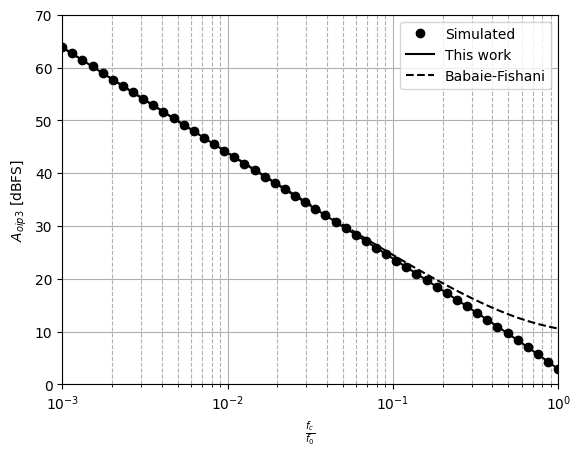

In [ ]:
plt.semilogx(fc / f0, 20 * np.log10(oip3_sim * np.sqrt(2)), 'ko', label="Simulated")
plt.semilogx(fc / f0, 20 * np.log10(oip3 * np.sqrt(2)), 'k', label="This work")
plt.semilogx(fc / f0, 20 * np.log10(oip3_old * np.sqrt(2)), 'k--', label="Babaie-Fishani")
plt.grid()
plt.grid(which='minor', linestyle='--')
plt.xlim(1e-3, 1e0)
plt.ylim(0, 70)
plt.xlabel(r"$\frac{f_c}{f_0}$")
plt.ylabel(r"$A_{oip3}$ [dBFS]")
plt.legend()
plt.show()

In [ ]:
np.savetxt("oip3-fc.csv", np.column_stack((fc / f0, oip3_sim, oip3, oip3_old)), delimiter=",", header="fc_over_f0,oip3_sim,oip3,oip3_old", comments="")

In [ ]:
# Predicted self-oscillation frequency by this work
f0 = 1
# Corner frequency of the loop filter
fc = 1e-2
# Design parameter
mu = np.exp(np.pi * fc / f0) - 1

V1 = 1 / (1 + mu ** (-1)) / np.log(1 + mu)

# Predicted OIP3
oip3_q = np.sqrt(2 / ((1 / 3 + mu ** (-1) + mu ** (-2)) * np.log(1 + mu) ** 2 - (1 / 2 + mu ** (-1)) * np.log(1 + mu)))

gu1 = 1
gu3 = -1 / (oip3_q ** 2 / 2 / V1 ** 2 / gu1)

# Corner frequency of the loop filter
fc_sim = f0 * np.logspace(-3, 0, 50)
# Design parameter
mu = np.exp(np.pi * fc_sim / f0) - 1
# Time delay of the quantizer
td_sim = np.log(mu / 2 + 1) / (2 * np.pi * fc_sim)

In [ ]:
V1_sim = np.zeros_like(fc_sim)
V3_sim = np.zeros_like(fc_sim)

for i, td_i in enumerate(td_sim):
    loop_filter = FilterFirstOrder(f_p = fc_sim[i], a = 1.0)
    quantizer = QuantizerDelayHysteresis(td_i, 0.0)
    quantizer.t_step = 0.05
    asdm = DeltaSigmaModulator(loop_filter, quantizer)

    U = np.linspace(-0.01, 0.01, 51)
    V_sim = np.zeros_like(U)

    for j, Uj in enumerate(U):
        v = asdm.simulate([BinaryWave(E=gu1 * Uj + gu3 * Uj ** 3)], n=10)

        assert np.isclose(v.e[-1] - v.e[-3], v.e[-3] - v.e[-5]), "Simulation failed to converge."
            
        V_sim[j] = v.E * (-1 + 2 * (v.e[-2] - v.e[-3]) / (v.e[-1] - v.e[-3]))
    
    res = np.polynomial.polynomial.polyfit(U, V_sim, 7)

    V1_sim[i] = res[1]
    V3_sim[i] = res[3]

In [ ]:
# Predicted self-oscillation frequency by this work
f0 = 1
# Corner frequency of the loop filter
fc = f0 * np.logspace(-3, 0, 1000)
# Design parameter
mu = np.exp(np.pi * fc / f0) - 1
# Time delay of the quantizer
td = np.log(mu / 2 + 1) / (2 * np.pi * fc)

# Predicted oip3
oip3_q = np.sqrt(2 / ((1 / 3 + mu ** (-1) + mu ** (-2)) * np.log(1 + mu) ** 2 - (1 / 2 + mu ** (-1)) * np.log(1 + mu)))

V1 = 1 / (1 + mu ** (-1)) / np.log(1 + mu)

oip3_gu = np.sqrt(2 * np.abs(V1 ** 2 * gu1 / gu3)) * np.ones_like(fc)

oip3 = 1 / np.sqrt(np.abs(-1 / oip3_gu ** 2 + 1 / oip3_q ** 2))

oip3[np.argmax(oip3)] = np.sqrt(2) * 10 ** (100 / 20)

# Simulated oip3
oip3_sim = np.sqrt(2 * np.abs(V1_sim ** 3 / V3_sim))

/tmp/ipykernel_2168526/2077072859.py:17: RuntimeWarning: divide by zero encountered in divide
  oip3 = 1 / np.sqrt(np.abs(-1 / oip3_gu ** 2 + 1 / oip3_q ** 2))


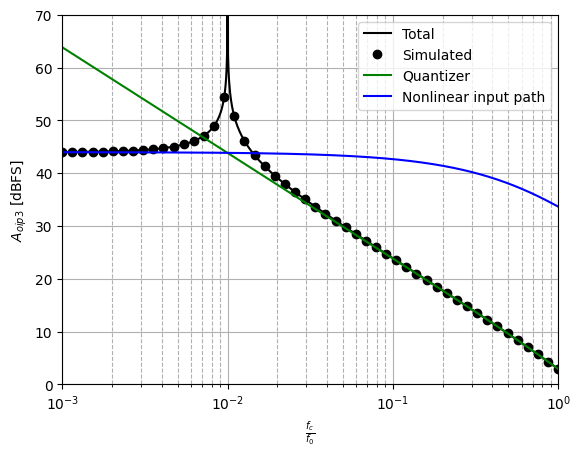

In [ ]:
plt.semilogx(fc / f0, 20 * np.log10(oip3 * np.sqrt(2)), 'k', label="Total")
plt.semilogx(fc_sim / f0, 20 * np.log10(oip3_sim * np.sqrt(2)), 'ko', label="Simulated")
plt.semilogx(fc / f0, 20 * np.log10(oip3_q * np.sqrt(2)), 'g', label="Quantizer")
plt.semilogx(fc / f0, 20 * np.log10(oip3_gu * np.sqrt(2)), 'b', label="Nonlinear input path")
plt.grid()
plt.grid(which='minor', linestyle='--')
plt.xlim(1e-3, 1e0)
plt.ylim(0, 70)
plt.xlabel(r"$\frac{f_c}{f_0}$")
plt.ylabel(r"$A_{oip3}$ [dBFS]")
plt.legend()
plt.show()

In [ ]:
np.savetxt("oip3-cancel.csv", np.column_stack((fc / f0, oip3, oip3_q, oip3_gu)), delimiter=",", header="fc_over_f0,oip3,oip3_q,oip3_gu", comments="")
np.savetxt("oip3-cancel-sim.csv", np.column_stack((fc_sim / f0, oip3_sim)), delimiter=",", header="fc_over_f0,oip3_sim", comments="")

In [ ]:
# Predicted self-oscillation frequency by this work
f0 = 1
# Corner frequency of the loop filter
fc = 1e-2
# Design parameter
mu = np.exp(np.pi * fc / f0) - 1
# Time delay of the quantizer
td = np.log(mu / 2 + 1) / (2 * np.pi * fc)
# Input amplitude
U = 0.1
# Predicted gain
V1 = 1 / (1 + mu ** (-1)) / np.log(1 + mu)
# Predicted OIP3
oip3_q = np.sqrt(2 / ((1 / 3 + mu ** (-1) + mu ** (-2)) * np.log(1 + mu) ** 2 - (1 / 2 + mu ** (-1)) * np.log(1 + mu)))
# Ideal gu3 for OIP3 cancellation
gu3_ideal = -1 / (oip3_q ** 2 / 2 / V1 ** 2)

# Nonlinear input path
gu1 = 1
gu3 = np.array([0, gu3_ideal, 0.9 * gu3_ideal, 0.8 * gu3_ideal])

# Fundamental and third-order phasor due to input nonlinearity
phasor_U1 = U + gu3 / gu1 * U ** 3 * 3 / 4
phasor_U3 =     gu3 / gu1 * U ** 3 * 1 / 4

In [ ]:
loop_filter = FilterFirstOrder(f_p = fc, a = 1.0)
loop_filter_integrator = FilterIntegrator(2 * np.pi * fc)
quantizer = QuantizerDelayHysteresis(td, 0.0)
quantizer.t_step = 0.05
asdm = DeltaSigmaModulator(loop_filter, quantizer)
asdm_integrator = DeltaSigmaModulator(loop_filter_integrator, quantizer)

In [ ]:
# Input frequency
fu = np.logspace(-4, -1, 20)
# Period count
n = 4

In [ ]:
v = np.empty((len(fu), len(gu3) + 1), dtype=object)

for j in range(len(gu3) + 1):
    for i, fu_i in enumerate(fu):
        print(f"Simulating for gu3 = {gu3[j] if j != len(gu3) else 0:.2e} and fu = {fu_i:.2e}...")

        # Stop time for the simulation
        ts = 4.0 / fu_i + n / fu_i

        if j == len(gu3):
            u = SineWave([0, U], fu_i)

            asdm_j = asdm_integrator
        else:
            u = SineWave([0, phasor_U1[j], 0, phasor_U3[j]], fu_i)

            asdm_j = asdm

        v[i, j] = asdm_j.simulate([u], t=ts)

Simulating for gu3 = 0.00e+00 and fu = 1.00e-04...
Progress: 100.0 %
Simulating for gu3 = 0.00e+00 and fu = 1.44e-04...
Progress: 100.0 %
Simulating for gu3 = 0.00e+00 and fu = 2.07e-04...
Progress: 100.0 %
Simulating for gu3 = 0.00e+00 and fu = 2.98e-04...
Progress: 100.0 %
Simulating for gu3 = 0.00e+00 and fu = 4.28e-04...
Progress: 100.0 %
Simulating for gu3 = 0.00e+00 and fu = 6.16e-04...
Progress: 100.0 %
Simulating for gu3 = 0.00e+00 and fu = 8.86e-04...
Progress: 100.0 %
Simulating for gu3 = 0.00e+00 and fu = 1.27e-03...
Progress: 100.0 %
Simulating for gu3 = 0.00e+00 and fu = 1.83e-03...
Progress: 100.0 %
Simulating for gu3 = 0.00e+00 and fu = 2.64e-03...
Progress: 100.0 %
Simulating for gu3 = 0.00e+00 and fu = 3.79e-03...
Progress: 100.0 %
Simulating for gu3 = 0.00e+00 and fu = 5.46e-03...
Progress: 100.0 %
Simulating for gu3 = 0.00e+00 and fu = 7.85e-03...
Progress: 100.0 %
Simulating for gu3 = 0.00e+00 and fu = 1.13e-02...
Progress: 100.1 %
Simulating for gu3 = 0.00e+00 and 

In [ ]:
v_filt_t = np.zeros((256, len(fu), len(gu3) + 1))

for j in range(len(gu3) + 1):
    for i, fu_i in enumerate(fu):
        print(f"Filtering for gu3 = {gu3[j] if j != len(gu3) else 0:.2e} and fu = {fu_i:.2e}...")

        # Cut-off frequency
        fc = 4 * fu_i
        # Sampling frequency
        fs = 16 * fc
        # Output filter
        output_filter = FilterButterworth(10, fc)
        # Time vector
        t = 4.0 / fu_i + np.arange(0.0, n / fu_i - 0.5 / fs, 1.0 / fs)

        v_filt_t[:, i, j] = v[i, j].filter(output_filter)(t)

w = np.ones(len(t))

w1 = np.linalg.norm(w, 1)

V_filt_f = np.fft.rfft(v_filt_t, axis=0) / (w1 / 2)

f = np.fft.rfftfreq(len(t), d=1.0 / fs)

phasor_V1 = V_filt_f[4, :, :]
phasor_V3 = V_filt_f[12, :, :]

V1_sim = phasor_V1 / U
V3_sim = phasor_V3 / U ** 3 * 4

oip3_sim = np.sqrt(2 * np.abs(V1_sim ** 3 / V3_sim))

Filtering for gu3 = 0.00e+00 and fu = 1.00e-04...
Filtering for gu3 = 0.00e+00 and fu = 1.44e-04...
Filtering for gu3 = 0.00e+00 and fu = 2.07e-04...
Filtering for gu3 = 0.00e+00 and fu = 2.98e-04...
Filtering for gu3 = 0.00e+00 and fu = 4.28e-04...
Filtering for gu3 = 0.00e+00 and fu = 6.16e-04...
Filtering for gu3 = 0.00e+00 and fu = 8.86e-04...
Filtering for gu3 = 0.00e+00 and fu = 1.27e-03...
Filtering for gu3 = 0.00e+00 and fu = 1.83e-03...
Filtering for gu3 = 0.00e+00 and fu = 2.64e-03...
Filtering for gu3 = 0.00e+00 and fu = 3.79e-03...
Filtering for gu3 = 0.00e+00 and fu = 5.46e-03...
Filtering for gu3 = 0.00e+00 and fu = 7.85e-03...
Filtering for gu3 = 0.00e+00 and fu = 1.13e-02...
Filtering for gu3 = 0.00e+00 and fu = 1.62e-02...
Filtering for gu3 = 0.00e+00 and fu = 2.34e-02...
Filtering for gu3 = 0.00e+00 and fu = 3.36e-02...
Filtering for gu3 = 0.00e+00 and fu = 4.83e-02...
Filtering for gu3 = 0.00e+00 and fu = 6.95e-02...
Filtering for gu3 = 0.00e+00 and fu = 1.00e-01...


/tmp/ipykernel_2168526/37754561.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


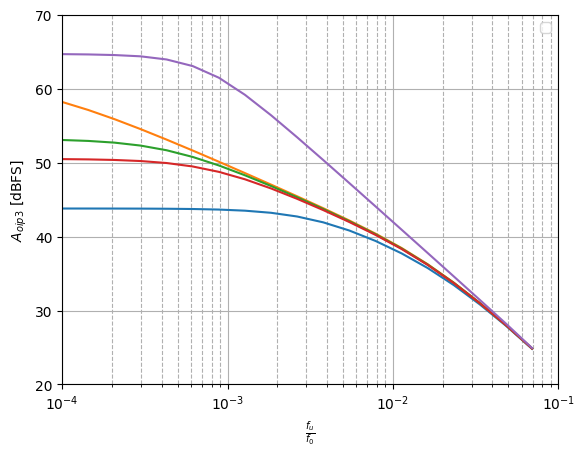

In [ ]:
plt.semilogx(fu[:-1] / f0, 20 * np.log10(oip3_sim[:-1, :] * np.sqrt(2)))
plt.xlim(1e-3, 1e-1)
plt.grid()
plt.grid(which='minor', linestyle='--')
plt.xlim(1e-4, 1e-1)
plt.ylim(20, 70)
plt.xlabel(r"$\frac{f_u}{f_0}$")
plt.ylabel(r"$A_{oip3}$ [dBFS]")
plt.legend()
plt.show()

In [ ]:
np.savetxt("oip3-cancel-sim-fu.csv", np.column_stack((fu[:-1] / f0, oip3_sim[:-1, :])), delimiter=",", header="fu_over_f0,oip3_sim", comments="")

In [ ]:
# Predicted self-oscillation frequency by this work
f0 = 1
# Corner frequency of the loop filter
fc = 1e-2
# Design parameter
mu = np.exp(np.pi * fc / f0) - 1
# Time delay of the quantizer
td = np.log(mu / 2 + 1) / (2 * np.pi * fc)
# Input frequency
fu = 1e-3
# Input amplitude
U = np.logspace(-3, -1, 20)
# Predicted gain
V1 = 1 / (1 + mu ** (-1)) / np.log(1 + mu)
# Predicted OIP3
oip3_q = np.sqrt(2 / ((1 / 3 + mu ** (-1) + mu ** (-2)) * np.log(1 + mu) ** 2 - (1 / 2 + mu ** (-1)) * np.log(1 + mu)))
# Ideal gu3 for OIP3 cancellation
gu3_ideal = -1 / (oip3_q ** 2 / 2 / V1 ** 2)

# Nonlinear input path
gu1 = 1
gu3 = np.array([0, gu3_ideal, 0.9 * gu3_ideal, 0.8 * gu3_ideal])

In [ ]:
v = np.empty((len(U), len(gu3) + 1), dtype=object)

for j in range(len(gu3) + 1):
    for i, U_i in enumerate(U):
        print(f"Simulating for gu3 = {gu3[j] if j != len(gu3) else 0:.2e} and U = {U_i:.2e}...")

        # Stop time for the simulation
        ts = 4.0 / fu + n / fu

        # Fundamental and third-order phasor due to input nonlinearity

        if j == len(gu3):
            u = SineWave([0, U_i], fu)

            asdm_j = asdm_integrator
        else:
            phasor_U1 = U_i + gu3[j] / gu1 * U_i ** 3 * 3 / 4
            phasor_U3 =       gu3[j] / gu1 * U_i ** 3 * 1 / 4

            u = SineWave([0, phasor_U1, 0, phasor_U3], fu)

            asdm_j = asdm

        v[i, j] = asdm_j.simulate([u], t=ts)

Simulating for gu3 = 0.00e+00 and U = 1.00e-03...
Progress: 98.1 %

KeyboardInterrupt: 

In [ ]:
v_filt_t = np.zeros((256, len(U), len(gu3) + 1))

for j in range(len(gu3) + 1):
    for i, U_i in enumerate(U):
        print(f"Filtering for gu3 = {gu3[j] if j != len(gu3) else 0:.2e} and U = {U_i:.2e}...")

        # Cut-off frequency
        fc = 4 * fu
        # Sampling frequency
        fs = 16 * fc
        # Output filter
        output_filter = FilterButterworth(10, fc)
        # Time vector
        t = 4.0 / fu + np.arange(0.0, n / fu - 0.5 / fs, 1.0 / fs)

        v_filt_t[:, i, j] = v[i, j].filter(output_filter)(t)

w = np.ones(len(t))

w1 = np.linalg.norm(w, 1)

V_filt_f = np.fft.rfft(v_filt_t, axis=0) / (w1 / 2)

f = np.fft.rfftfreq(len(t), d=1.0 / fs)

phasor_V1 = V_filt_f[4, :, :]
phasor_V3 = V_filt_f[12, :, :]

hd3_sim = np.abs(phasor_V3 / phasor_V1)

Filtering for gu3 = 0.00e+00 and U = 1.00e-03...
Filtering for gu3 = 0.00e+00 and U = 1.27e-03...


KeyboardInterrupt: 

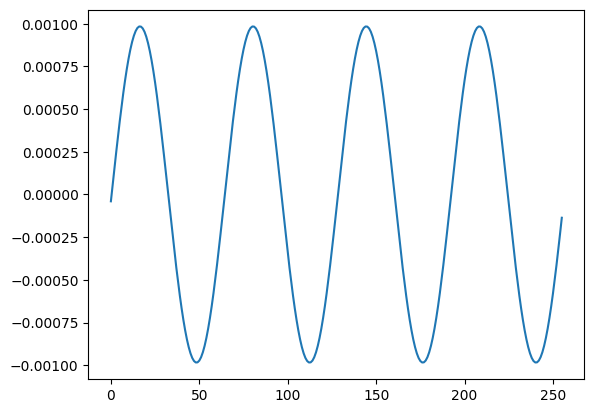

In [ ]:
plt.plot(v_filt_t[:, 0, 0])

/tmp/ipykernel_2168526/3279158100.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


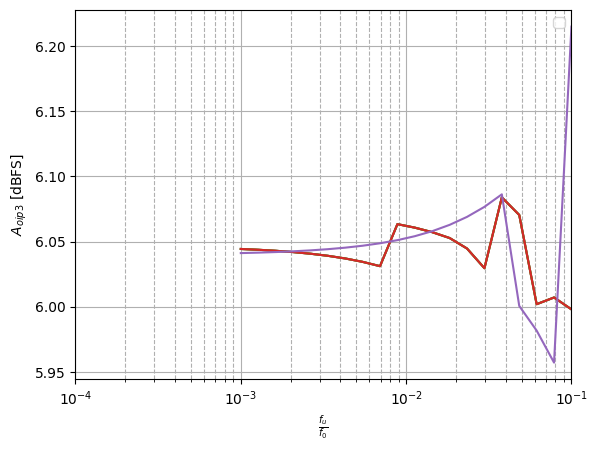

In [ ]:
plt.semilogx(U, 20 * np.log10(hd3_sim))
plt.xlim(1e-3, 1e-1)
plt.grid()
plt.grid(which='minor', linestyle='--')
plt.xlim(1e-4, 1e-1)
# plt.ylim(20, 70)
plt.xlabel(r"$\frac{f_u}{f_0}$")
plt.ylabel(r"$A_{oip3}$ [dBFS]")
plt.legend()
plt.show()

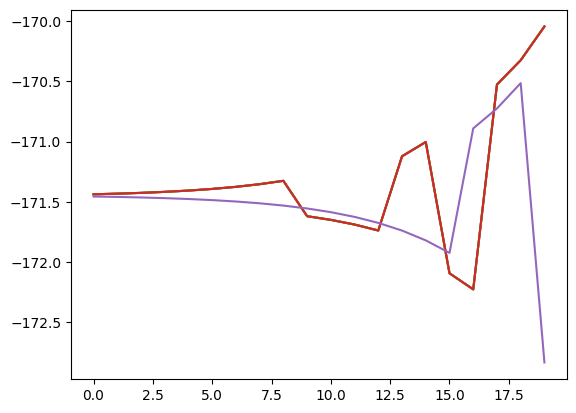

In [ ]:
plt.plot(20 * np.log10(np.abs(phasor_V1)))